# SHEETAL PATIL | Accredian Assignment- Instructor Effectiveness Modeling

**1. Problem Context**\
Working with an EdTech platform that runs the same course across multiple batches taught by different instructors.\
Each instructor may teach:\
● Multiple batches\
● The same course across different batches\
● Different courses across time

The company wants to better understand instructor effectiveness using available data from learner outcomes, engagement, and feedback.\
The task is to analyze the data, define instructor effectiveness, and build an ML model to predict instructor effectiveness tiers. 

In [36]:
#load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [37]:
#read/load the data
data = pd.read_csv("D://WORK//NewInternshala//Accredian//instructor_effectiveness_dataset.csv")
data

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,B_1131,I_047,C_17,0.589309,19.227979,46.242023,0.433437,0.848756,0.641781,0.261656,4.339478,0.643116
1996,B_1295,I_037,C_25,0.980000,36.737265,93.249093,0.103561,1.000000,0.688175,0.375195,4.912936,0.959988
1997,B_0861,I_033,C_06,0.531447,24.907878,83.990693,0.512266,0.918924,0.598276,0.271701,4.211113,0.773437
1998,B_1460,I_069,C_10,0.641025,22.395362,80.044231,0.317231,0.558183,0.575629,0.135500,4.182141,0.962627


#### Data Understanding

Each row represents one course batch.\
The dataset has over 2000 batches and 11 variables.There is a variable named ‘avg_quiz_score’ that indicates actual status of an instructor effectiveness. This is the class variable for our analysis.

The columns in the dataset are described as follows:\
**1. batch_id-** Unique ID for a course batch\
**2. instructor_id-** Unique instructor identifier\
**3. course_id-** Course identifier\
**4. completion_rate-** Fraction of learners who completed the course (0–1)\
**5. dropout_rate-** Fraction of learners who dropped out (0–1)\
**6. avg_score_improvement-** Average improvement from pre- to post-assessment\
**7. avg_quiz_score-** Average quiz score for the batch\
**8. avg_watch_time-** Normalized average video watch time (0–1)\
**9. assignment_submission_rate-** Fraction of learners submitting assignments\
**10. forum_activity_rate-** Fraction of learners active on discussion forums\
**11. avg_feedback_score-** Average learner feedback rating (1–5)\
**12. feedback_response_rate-** Fraction of learners who submitted feedback 

**Dataset Overview**\
**Learning outcomes:** avg_score_improvement, avg_quiz_score

**Engagement:** avg_watch_time, forum_activity_rate

**Completion metrics:** completion_rate, dropout_rate

**Assignment behavior:** assignment_submission_rate

**Student feedback:** avg_feedback_score, feedback_response_rate

In [38]:
# Data's Structure 
type(data)

pandas.core.frame.DataFrame

In [39]:
# rows and columns
data.shape

(2000, 12)

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


All the Identifier Columns, batch_id, instructor_id, course_id are of object type and all other columns are of float type. Also memory usage is shown which is 187.6+ KB.

In [41]:
#checking whether null values are there in the dataset using isna()
data.isna().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [42]:
# Summary Statistics
#see the range of data (analysis of the numerical data)
data.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


Maximum value of avg_quiz_score is 100 and minimum is 40.38. Also mean is good, which is 77.95.\
avg_watch_time column's mean is also in good status, which is 0.7765.\
dropout_rate column's mean is less which is 0.3948

In [43]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool

In [44]:
#Count of duplicated rows
data[data.duplicated()].shape

(0, 12)

In [45]:
# List unique counts for IDs
print("\n--- Unique Counts ---")
print(f"Batches: {data['batch_id'].nunique()}")
print(f"Instructors: {data['instructor_id'].nunique()}")
print(f"Courses: {data['course_id'].nunique()}")


--- Unique Counts ---
Batches: 2000
Instructors: 120
Courses: 25


Here in the dataset, total cources are 25, instructors are 120 and batches are 2000.

## Step 1: Exploratory Data Analysis

In [46]:
# Columns to plot
cols_to_plot = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
                'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
                'avg_feedback_score', 'feedback_response_rate']

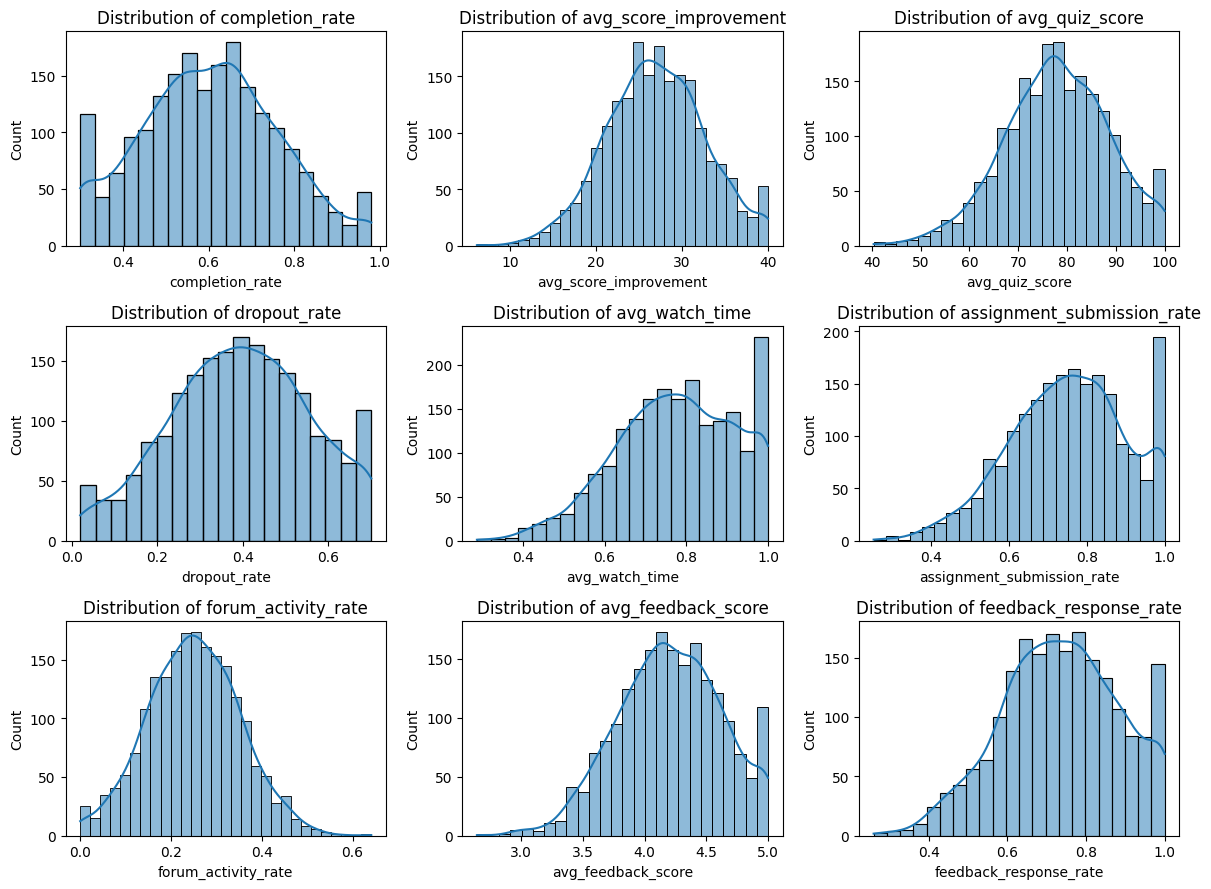

In [47]:
# Distribution of Numerical Features
plt.figure(figsize=(12, 9))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Insight for **Distribution of Completion Rate**: Helps identify whether most courses have high or low completion.\
Insight for **Distribution of Dropout Rate**: High dropout batches may indicate ineffective teaching or difficult content.\
Insight for **Score Improvement Distribution**: Shows whether instructors are helping students improve significantly.\
Insight for **feedback score distribution**: Indicates overall student satisfaction levels.

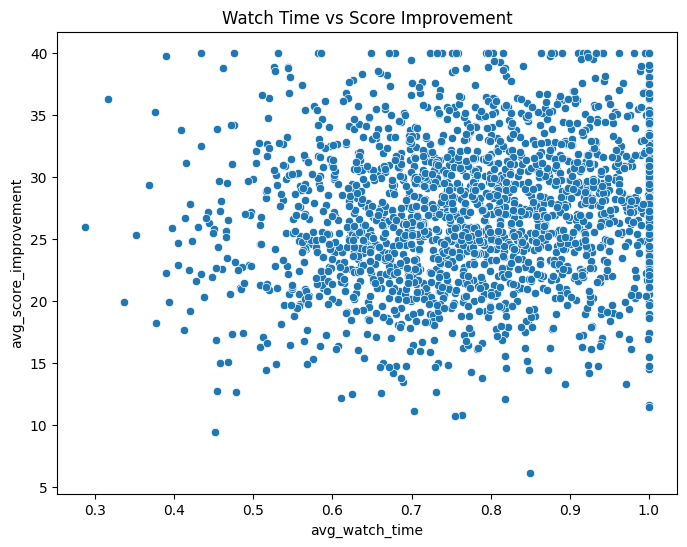

In [48]:
# Engagement vs Learning Outcome
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='avg_watch_time',
    y='avg_score_improvement',
    data=data
)
plt.title("Watch Time vs Score Improvement")
plt.show()

Insight: Shows whether watching more lectures improves learning outcomes.

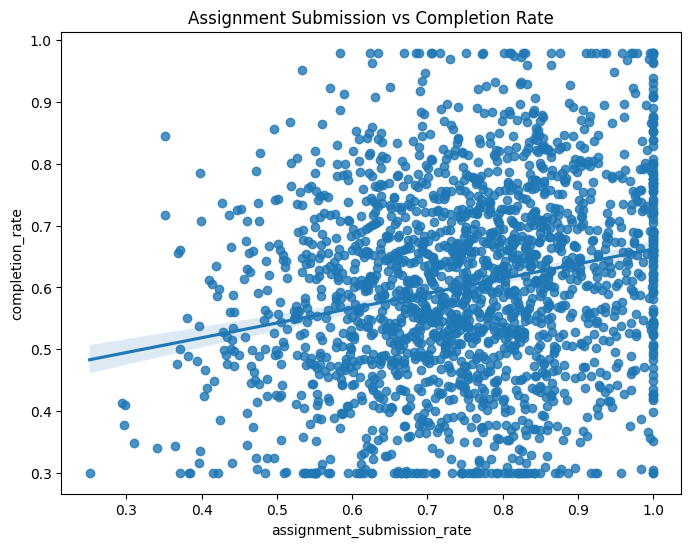

In [49]:
# Assignment Submission vs Completion Rate
plt.figure(figsize=(8,6))
sns.regplot(
    x='assignment_submission_rate',
    y='completion_rate',
    data=data
)
plt.title("Assignment Submission vs Completion Rate")
plt.show()

Insight: High assignment activity usually leads to higher course completion.

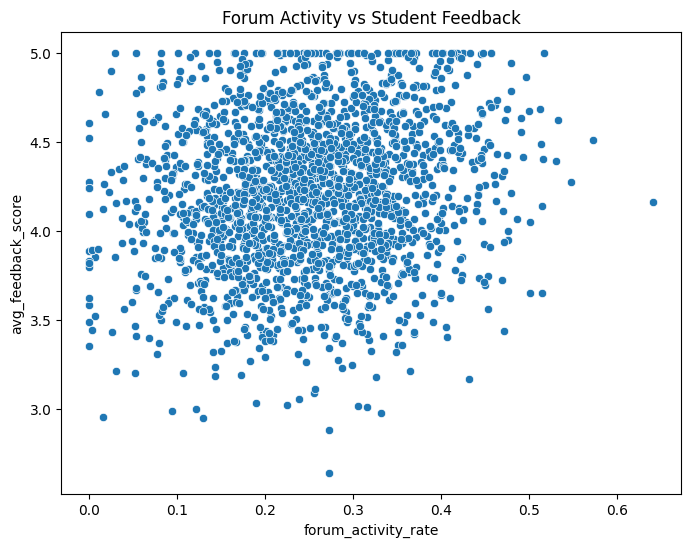

In [50]:
# Forum Activity vs Feedback Score
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='forum_activity_rate',
    y='avg_feedback_score',
    data=data
)
plt.title("Forum Activity vs Student Feedback")
plt.show()

Insight: Interactive instructors often receive better feedback.

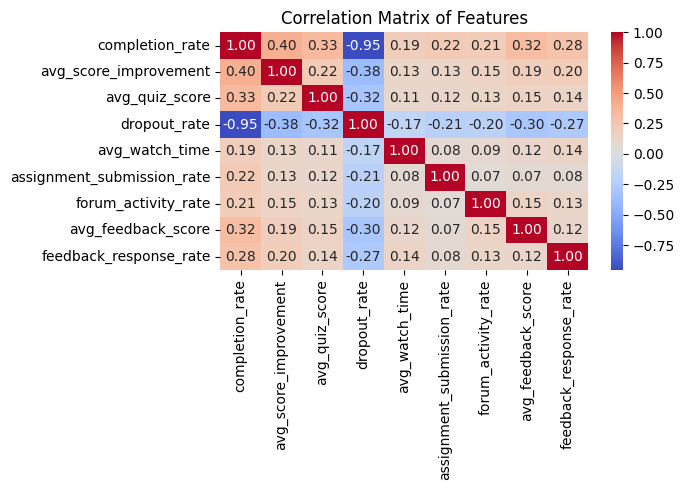

In [51]:
# Correlation Matrix
plt.figure(figsize=(7, 5))
correlation_matrix = data[cols_to_plot].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

Insight: Helps detect multicollinearity and important relationships.

In [52]:
# To Define Instructor Effectiveness Score, First, normalize the relevant columns to 0-1 range to make weights comparable
scaler = MinMaxScaler()
cols_for_score = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
                  'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
                  'avg_feedback_score', 'feedback_response_rate']

In [53]:
df_scaled = data.copy()
df_scaled[cols_for_score] = scaler.fit_transform(data[cols_for_score])
df_scaled

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.000000,0.238373,0.556249,0.922681,0.683637,0.720811,0.169103,0.477227,0.369235
1,B_0354,I_119,C_06,0.525324,0.493839,0.619419,0.595732,0.291198,0.998085,0.437599,1.000000,0.640690
2,B_1334,I_050,C_03,0.000000,0.293382,0.657185,1.000000,0.968987,0.742683,0.322898,0.371797,0.569542
3,B_0906,I_024,C_21,0.499274,0.534901,0.988179,0.462731,0.784601,0.391839,0.477913,0.664240,1.000000
4,B_1290,I_001,C_08,0.334267,0.736459,0.989825,0.736911,0.884150,0.820915,0.393519,0.756886,0.590184
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,B_1131,I_047,C_17,0.425454,0.386183,0.098221,0.607995,0.787746,0.521666,0.408129,0.720128,0.517766
1996,B_1295,I_037,C_25,1.000000,0.903586,0.886755,0.122884,1.000000,0.583616,0.585226,0.963110,0.945935
1997,B_0861,I_033,C_06,0.340363,0.554025,0.731447,0.723920,0.886218,0.463573,0.423797,0.665738,0.693860
1998,B_1460,I_069,C_10,0.501507,0.479780,0.665246,0.437105,0.379958,0.433333,0.211351,0.653462,0.949500


## Step 2: Define Instructor Effectiveness Score

To measure performance objectively, created an Instructor Effectiveness Score (0 to 1 scale) using a weighted combination of key performance indicators (KPIs):\
**A composite score is created using:**

Completion Rate\
Score Improvement\
Quiz Score\
Dropout Rate\
Assignment Submission Rate\
Forum Activity\
Student Feedback

|  **Metric**   |  **Weight**	|   **Rationale**   |

| Completion Rate|	25%	 |Success in guiding students through the entire curriculum.|\
| Score Improvement|	20%	 |Primary evidence of actual learning and knowledge gain.|\
| Quiz Scores|	15%	 |Indicator of student mastery of the specific batch material.|\
| Retention (1 - Dropout)|	10%	 |Critical for business; measures the ability to keep students engaged.|\
| Assignment Submission| 10%  |Student's involvement for the activity given.|\
| Engagement (Watch/Forum)|	10%	 |Proxy for student motivation and instructor's ability to foster community.|\
| Feedback Score|	10%	 | Reflects student satisfaction and perceived instructor quality.|\

In [54]:
data['effectiveness_score'] = (
    
    0.25 * df_scaled['avg_score_improvement'] +
    0.20 * (df_scaled['avg_feedback_score']) +
    0.15 * df_scaled['completion_rate'] +
    0.15 * (1 - df_scaled['dropout_rate']) +
    0.10 * (df_scaled['avg_quiz_score']) +
    0.10 * df_scaled['avg_watch_time'] +
    0.05 * df_scaled['assignment_submission_rate'] +
    0.05 * df_scaled['forum_activity_rate'] +
    0.10 * df_scaled['feedback_response_rate']
)

data[['effectiveness_score']].head()

,effectiveness_score
0,0.372044
1,0.689813
2,0.420555
3,0.742820
4,0.732233


## Step 3: Aggregating Batch Data to Instructor Level
Since effectiveness is an inherent trait of the instructor, batch-level data was aggregated to create a single profile per instructor:\
**•	Aggregation Function:** Arithmetic Mean was used for all metrics. This averages out the "noise" from particularly difficult or easy batches.\
**•	Handling Batch Volume:**\
o	Instructors have between 7 and 31 batches (average 16.7).\
o	Because even the least-active instructors have at least 7 batches, the mean is statistically robust enough to represent their typical performance without needing to exclude anyone.


In [55]:
instructor_stats = data.groupby('instructor_id').agg({
    'completion_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'dropout_rate': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'effectiveness_score': 'mean',
    'batch_id': 'count'
}).rename(columns={'batch_id': 'batch_count'}).reset_index()

In [56]:
# Define Tiers based on Quantiles (Low 33%, Mid 33%, High 33%)
low_thresh = instructor_stats['effectiveness_score'].quantile(0.33)
high_thresh = instructor_stats['effectiveness_score'].quantile(0.67)

def get_tier(score):
    if score <= low_thresh: return 'Low'
    elif score <= high_thresh: return 'Medium'
    else: return 'High'

instructor_stats['tier'] = instructor_stats['effectiveness_score'].apply(get_tier)
instructor_stats['tier'].value_counts()

tier
Medium    40
High      40
Low       40
Name: count, dtype: int64

**Effectiveness Tiers:**
Based on this score, instructors were categorized into three tiers using quantiles to ensure a balanced distribution for the classification model:\
•	Low: Bottom 33% of instructors.\
•	Medium: Middle 33% of instructors.\
•	High: Top 33% of instructors.

**Class Imbalance**\
Classes are relatively balanced due to quantile-based tiering.

In [57]:
instructor_stats.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count,tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,0.630559,25,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,0.791534,20,High
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,0.811942,18,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,0.561512,17,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,0.866799,19,High


In [58]:
# Check batch counts distribution
print("\n--- Batch Count Distribution ---")
print(instructor_stats['batch_count'].describe())


--- Batch Count Distribution ---
count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: batch_count, dtype: float64


Insight: Every instructor has at least 7 batches and maximum 31.\
Each instructor must have liberal batches so that to enhance quality of teaching.

## Step 4: Buid the Machine Learning Model

Trained a Random Forest Classifier to predict an instructor's effectiveness tier based on their performance metrics.\
•	Algorithm: Random Forest was chosen because it handles non-linear relationships well and provides clear "Feature Importance" to understand what makes an instructor successful.\
•	Data Split: 80% training, 20% testing.

In [59]:
features = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
            'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
            'avg_feedback_score', 'feedback_response_rate']

In [60]:
X = instructor_stats[features]
y = instructor_stats['tier']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify=y)

In [62]:
model = RandomForestClassifier(n_estimators=100, random_state= 42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Trained a Random Forest Classifier to predict an instructor's effectiveness tier based on their performance metrics.\
•	Algorithm: Random Forest was chosen because it handles non-linear relationships well and provides clear "Feature Importance" to understand what makes an instructor successful.\
•	Data Split: 80% training, 20% testing (stratified by tier).

## Step 5: Model Evaluation

In [63]:
# Evaluate the Model
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:")
print(report)


--- Model Evaluation ---
Accuracy: 0.92
Classification Report:
              precision    recall  f1-score   support

        High       0.89      1.00      0.94         8
         Low       1.00      0.88      0.93         8
      Medium       0.88      0.88      0.88         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



•	Trade-offs: The model is perfect at identifying "High" performers (100% precision/recall). There is a slight overlap between "Low" and "Medium" categories, where some Low-tier instructors were predicted as Medium (leading to 80% recall for the Low tier).\
•	Class Imbalance: Not an issue here as we defined tiers based on quantiles (33/33/33 split).


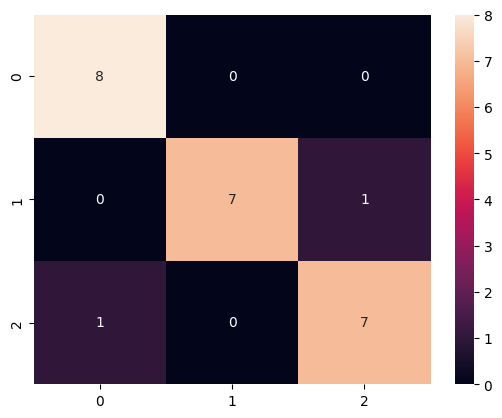

In [64]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

## Step 6: Feature Importance

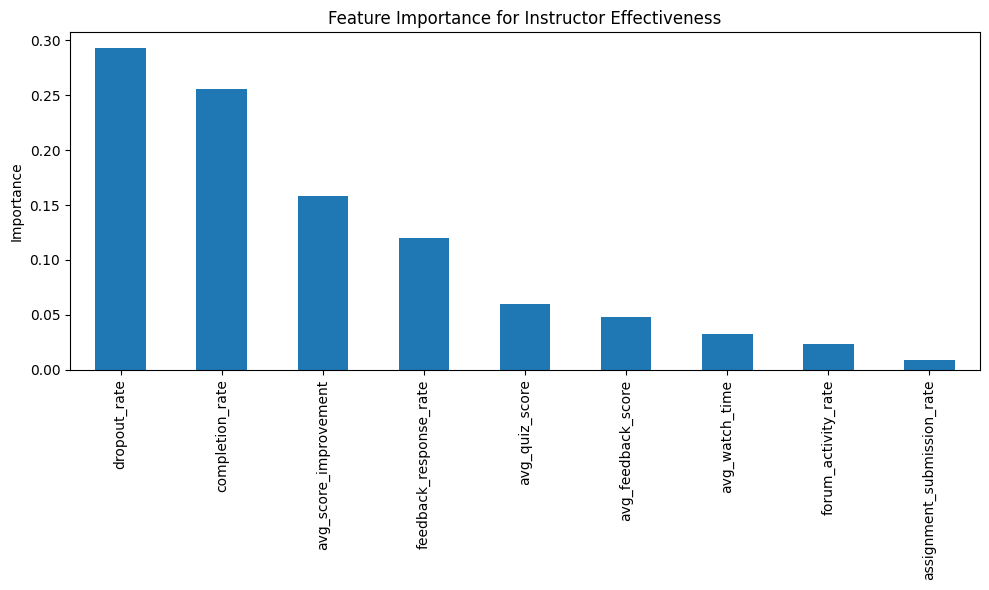


--- Feature Importance ---
dropout_rate                  0.292675
completion_rate               0.255786
avg_score_improvement         0.157817
feedback_response_rate        0.120433
avg_quiz_score                0.059619
avg_feedback_score            0.048351
avg_watch_time                0.032252
forum_activity_rate           0.023730
assignment_submission_rate    0.009336
dtype: float64


In [65]:
# Interpret the Results
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='bar')
plt.title('Feature Importance for Instructor Effectiveness')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print("\n--- Feature Importance ---")
print(feat_importances)

The model identified three dominant factors that separate top-tier instructors from the rest:\
**1.	Dropout Rate (29% Importance):** Closely related to completion, this highlights the instructor's ability to prevent student "churn."\
**2.	Completion Rate (25% Importance):** The strongest predictor. Top instructors don't just teach; they ensure students cross the finish line.\
**3.	Score Improvement (15% Importance):** Effectiveness is ultimately validated by how much the students' knowledge grew during the course.

### Interpretation

Important features influencing instructor effectiveness typically include:

- Completion rate
- Student score improvement
- Assignment submission rate
- Student feedback score
- Dropout rate

These indicators reflect both **student success and engagement**, which are strong signals of effective teaching.

**Product Insights**\
This model could power an Instructor Analytics Dashboard.\
Use Cases

1. Instructor Performance Monitoring\
Automatically classify instructors.

2. Early Warning System\
Identify instructors trending toward low effectiveness.

3. Instructor Training Programs\
Identify improvement areas.

4. Course Allocation\
Assign important courses to high-performing instructors.

**Business Recommendations:**\
•	Targeted Training: Instructors in the "Low" tier should be mentored specifically on "Student Retention" and "Engagement" techniques, as these are the biggest differentiators.\
•	Reward "High" Performers: Use the top-tier instructors as mentors or course designers, as they have proven ability to drive both learning outcomes (scores) and business outcomes (completion).\
•	In-Product Dashboard: Integrate these scores into an instructor dashboard. By showing instructors their "Predicted Tier" and identifying which metric (e.g., Forum Activity) is dragging them down, they can self-correct in real-time.
